In [18]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [19]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/ashyou09/global-deforestation-and-afforestation-2000-2025/global_deforestation_2000_2025.csv')
print(df.shape)
print(df.head())
print('\n')
print('columns:', df.columns.tolist())

(5720, 9)
  Country  Year  Forest_Area_km2  Land_Area_km2  Forest_Cover_Pct  \
0  Brazil  2000          5468301        8515767             64.21   
1  Brazil  2001          5439758        8515767             63.88   
2  Brazil  2002          5408757        8515767             63.51   
3  Brazil  2003          5326870        8515767             62.55   
4  Brazil  2004          5280984        8515767             62.01   

   Annual_Deforestation_Rate  Annual_Afforestation_Rate  \
0                       0.00                       0.00   
1                       1.07                       0.55   
2                       1.43                       0.86   
3                       1.56                       0.05   
4                       0.94                       0.08   

   Total_Carbon_Stock_Tonnes Primary_Driver_of_Change  
0                87197411954            Initial State  
1                86742262748                      NaN  
2                86247929409                      Na

In [20]:
# Checking Null values and dtypes
print(df.isnull().sum())
print(df.dtypes)

Country                         0
Year                            0
Forest_Area_km2                 0
Land_Area_km2                   0
Forest_Cover_Pct                0
Annual_Deforestation_Rate       0
Annual_Afforestation_Rate       0
Total_Carbon_Stock_Tonnes       0
Primary_Driver_of_Change     4376
dtype: int64
Country                       object
Year                           int64
Forest_Area_km2                int64
Land_Area_km2                  int64
Forest_Cover_Pct             float64
Annual_Deforestation_Rate    float64
Annual_Afforestation_Rate    float64
Total_Carbon_Stock_Tonnes      int64
Primary_Driver_of_Change      object
dtype: object


In [21]:
# Dropping Column
df.drop('Primary_Driver_of_Change', axis=1,inplace=True)
print(df.shape)

(5720, 8)


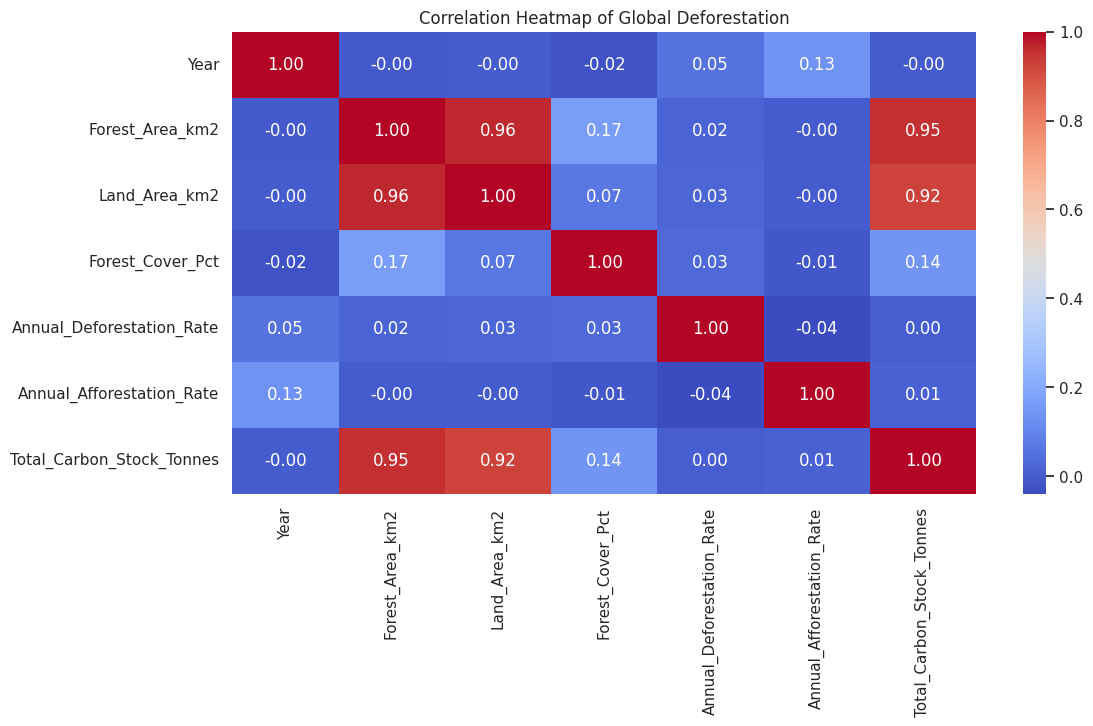

In [23]:
# Correlation HeatMap
plt.figure(figsize=(12,6))
corr = df.corr(numeric_only=True)

sns.heatmap(data=corr, annot=True, fmt='.2f', cbar=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Global Deforestation')
plt.show()

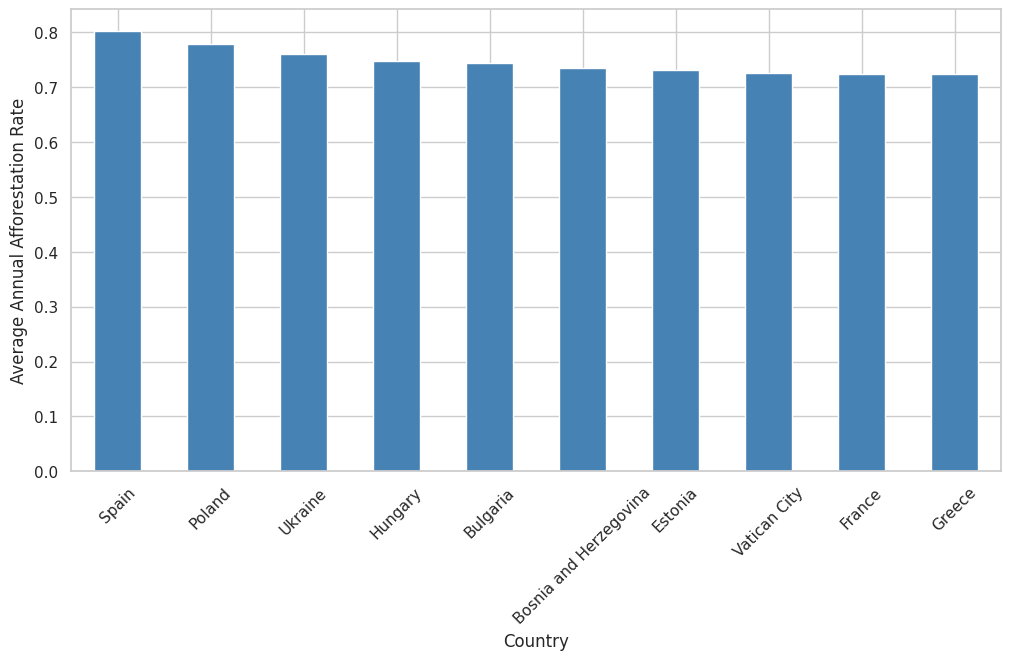

In [27]:
# Top Countries with highest afforestation
top_affor = df.groupby('Country')['Annual_Afforestation_Rate'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_affor.plot(kind='bar', color='steelblue')
plt.xlabel('Country')
plt.ylabel('Average Annual Afforestation Rate')
plt.xticks(rotation=45)
plt.show()

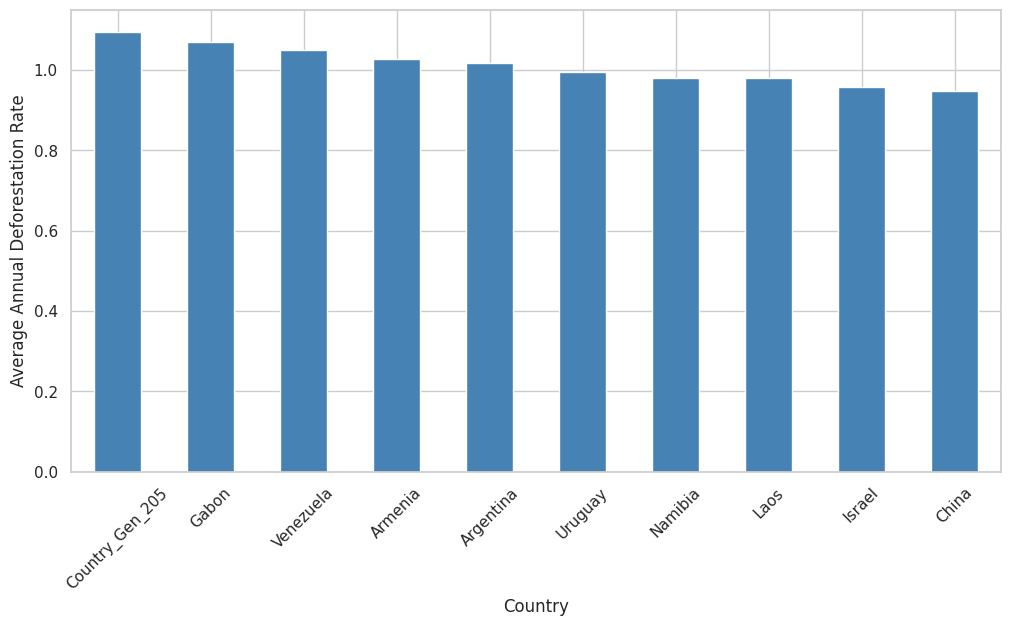

In [28]:
# Top Countries with highest deforestation
top_affor = df.groupby('Country')['Annual_Deforestation_Rate'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_affor.plot(kind='bar', color='steelblue')
plt.xlabel('Country')
plt.ylabel('Average Annual Deforestation Rate')
plt.xticks(rotation=45)
plt.show()

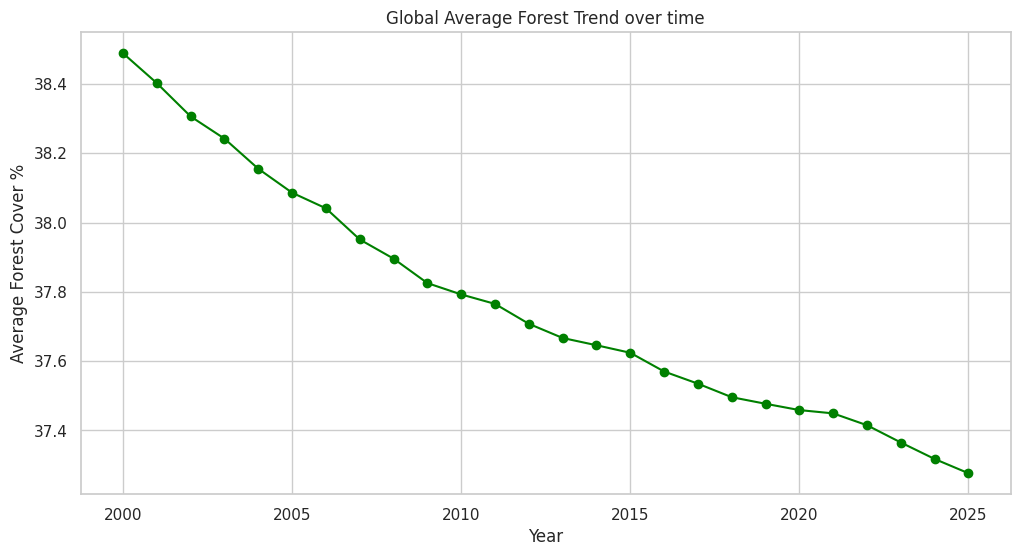

In [30]:
# Global Forest Trend over time
plt.figure(figsize=(12,6))
avg_forest = df.groupby('Year')['Forest_Cover_Pct'].mean()

plt.plot(avg_forest.index, avg_forest.values, marker='o', color='green')
plt.title('Global Average Forest Trend over time')
plt.xlabel('Year')
plt.ylabel('Average Forest Cover %')
plt.grid(True)
plt.show()

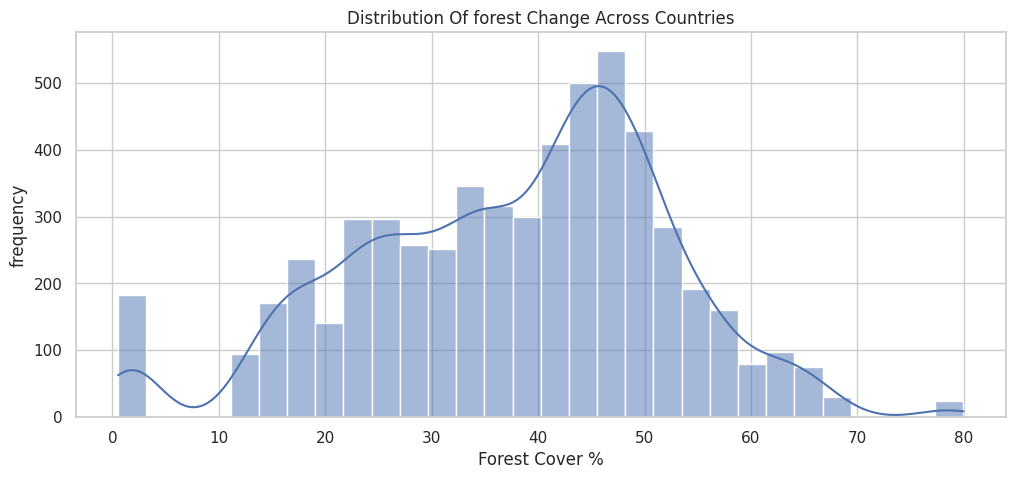

In [33]:
# Distribution Of forest Change percentage
plt.figure(figsize=(12,5))
sns.histplot(df['Forest_Cover_Pct'], bins=30, kde=True)
plt.title('Distribution Of forest Change Across Countries')
plt.xlabel('Forest Cover %')
plt.ylabel('frequency')
plt.show()